In [2]:
from google.colab import drive

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
 ls


drive/  sample_data/


In [5]:
cd drive

/content/drive


In [6]:
cd MyDrive

/content/drive/MyDrive


In [7]:
ls

'Colab Notebooks'/   smartdataset.csv     smartrestaurant.h5
 encoder.h5         'smart restaurant'/   websites/


# Datapreprocessing(creating adjacency matrix from a CSV file)

In [9]:
import pandas as pd
import networkx as nx
import numpy as np
import chardet
import pandas as pd

with open('smartdataset.csv', 'rb') as f:
    enc = chardet.detect(f.read())  # or readline if the file is large

df=pd.read_csv('smartdataset.csv', encoding = enc['encoding'])
disheslist=[]
adjmatrix=np.zeros([4893,4893])
# Assuming your data is in a CSV file, you can read it into a DataFrame
# Replace 'dataset.csv' with the actual file name/path
#df = pd.read_csv(r'lates/smartdataset.csv')


# Create a directed graph
G = nx.DiGraph()
m=0
# Iterate through each row in the DataFrame and add edges to the graph
for index, row in df.iterrows():
    # Extract dishes from the row
    dishes = row.tolist()

    # Iterate through the dishes and add edges between them
    for i in range(1):

        for j in range(i + 1, len(dishes)):



            # Adding an edge for each pair of dishes
            G.add_edge(dishes[i], dishes[j])
            G.add_edge(dishes[j], dishes[i])

# Create an adjacency matrix from the graph
adjacency_matrix = nx.adjacency_matrix(G).todense()

# Display the adjacency matrix

print(adjacency_matrix.shape)

(4893, 4893)


In [ ]:
adjacency_matrix[0][0:1000]

array([0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,

In [ ]:
nodes_list = list(G.nodes())

In [ ]:
nodes_list[3]

'chutney'

# Training the model


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D
num_samples = 4893
 # Assuming RGB images

X_train =adjacency_matrix
num_rows, num_columns = X_train.shape

# Add two extra rows at the end
extra_rows = np.zeros((3, num_columns))
matrix_with_extra_rows = np.concatenate((X_train, extra_rows), axis=0)

# Add two extra columns at the end
extra_columns = np.zeros((matrix_with_extra_rows.shape[0], 3))
X_train = np.concatenate((matrix_with_extra_rows, extra_columns), axis=1)
# Define the input shape and the number of filters in each layer
input_shape = (4896, 1)

# Encoder
encoder_input = Input(shape=input_shape)
x = Conv1D(16, kernel_size=3, activation='relu', padding='same')(encoder_input)
x = MaxPooling1D(pool_size=2, padding='same')(x)
x = Conv1D(8, kernel_size=3, activation='relu', padding='same')(x)
x = MaxPooling1D(pool_size=2, padding='same')(x)
x = Conv1D(4, kernel_size=3, activation='relu', padding='same')(x)
x = MaxPooling1D(pool_size=2, padding='same')(x)

encoded = Conv1D(1, kernel_size=3, activation='relu', padding='same')(x)

# Decoder

x = Conv1D(4, kernel_size=3, activation='relu', padding='same')(encoded)
x = UpSampling1D(size=2)(x)
x = Conv1D(8, kernel_size=3, activation='relu', padding='same')(x)
x = UpSampling1D(size=2)(x)
x = Conv1D(16, kernel_size=3, activation='relu', padding='same')(x)
x = UpSampling1D(size=2)(x)
decoded = Conv1D(1, kernel_size=3, activation='sigmoid', padding='same')(x)

# Create and compile the autoencoder model
autoencoder = Model(encoder_input, decoded)
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

# Print the model summary
autoencoder.summary()
X_train=X_train.reshape(4896,4896,1)
autoencoder.fit(X_train, X_train, epochs=20, batch_size=64, shuffle=True)



Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 4896, 1)]         0         
                                                                 
 conv1d (Conv1D)             (None, 4896, 16)          64        
                                                                 
 max_pooling1d (MaxPooling1  (None, 2448, 16)          0         
 D)                                                              
                                                                 
 conv1d_1 (Conv1D)           (None, 2448, 8)           392       
                                                                 
 max_pooling1d_1 (MaxPoolin  (None, 1224, 8)           0         
 g1D)                                                            
                                                                 
 conv1d_2 (Conv1D)           (None, 1224, 4)           100 

In [ ]:
autoencoder.save('smartrestaurant.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [13]:
from tensorflow.keras.models import load_model
autoencoder = load_model('smartrestaurant.h5')

In [14]:
X_train =adjacency_matrix
num_rows, num_columns = X_train.shape

# Add two extra rows at the end
extra_rows = np.zeros((3, num_columns))
matrix_with_extra_rows = np.concatenate((X_train, extra_rows), axis=0)

# Add two extra columns at the end
extra_columns = np.zeros((matrix_with_extra_rows.shape[0], 3))
X_train = np.concatenate((matrix_with_extra_rows, extra_columns), axis=1)

In [15]:
element_to_find = 'squid roast'
nodes_list = list(G.nodes())
# Get the index of the element
element_index = nodes_list.index(element_to_find)

# Print the index
print(f"The index of '{element_to_find}' is: {element_index}")

The index of 'squid roast' is: 320


# testing the model

In [16]:

from tensorflow.keras.models import Model
layer_name = 'conv1d_3'  # Replace with the name of the layer you want to extract
intermediate_layer_model = Model(inputs=autoencoder.input, outputs=autoencoder.get_layer(layer_name).output)
intermediate_output = intermediate_layer_model.predict(X_train)
print(intermediate_output.shape)
def cosine_similarity(vector1, vector2):
    """
    Calculate the cosine similarity between two vectors.

    Parameters:
    - vector1, vector2: 1D NumPy arrays representing the vectors.

    Returns:
    - Similarity score between -1 and 1.
    """
    dot_product = np.dot(vector1, vector2)
    norm_vector1 = np.linalg.norm(vector1)
    norm_vector2 = np.linalg.norm(vector2)

    similarity = dot_product / (norm_vector1 * norm_vector2)

    return similarity

user_id = element_index  # Replace with the desired user

user_representation = (intermediate_output[user_id]).flatten()
print(user_representation.shape)
flattened_array = intermediate_output.reshape((intermediate_output.shape[0], -1))
print(flattened_array[0].shape)
# Calculate cosine similarity between the user and all products
similarities=np.zeros(4896)
for i in range(0,4896):
    similarities[i] = cosine_similarity(user_representation,flattened_array[i])

# Get product recommendations for the user
num_recommendations = 4
recommended_products = np.argsort(similarities)[-num_recommendations:][::-1]

print("User {} Recommendations:".format(user_id))
print(recommended_products)
for item in recommended_products:
     print(nodes_list[item])

153/153 [==============================] - 5s 28ms/step
(4896, 612, 1)
(612,)
(612,)
User 320 Recommendations:
[320 321 318 324]
squid roast
squid sukka
squid biriyani
squid masala


In [ ]:
similarities[320]

1.0

In [ ]:
user_representation

In [ ]:
flattened_array[4893]


# evaluation metrics


In [ ]:
import numpy as np

def precision_at_k(actual, predicted, k):
    """
    Calculate Precision at K.

    Parameters:
    - actual: List of lists, where each sublist contains actual relevant items for a user.
    - predicted: List of lists, where each sublist contains predicted items for a user.
    - k: Number of recommendations to consider.

    Returns:
    - Average Precision at K across all users.
    """
    num_users = len(actual)
    total_precision_at_k = 0.0

    for i in range(num_users):
        actual_items = actual[i]
        predicted_items = predicted[i][:k]

        actual_set = set(actual_items)
        num_relevant_at_k = len(set(predicted_items).intersection(actual_set))
        precision_at_k = num_relevant_at_k / k if k > 0 else 0.0

        total_precision_at_k += precision_at_k

    average_precision_at_k = total_precision_at_k / num_users
    return average_precision_at_k


In [ ]:
# Example usage
actual_items_list = ["squid roast", "squid fry", "squid masala", "squid sukka"] # List of actual relevant items for each user
predicted_items_list =['squid roast', 'squid sukka', 'squid biriyani', 'squid masala', 'squid fry'] # List of predicted items for each user

k = 10 # Top-K recommendations to consider
average_precision_at_k = precision_at_k(actual_items_list, predicted_items_list, k)
print(f'Average Precision at {k}: {average_precision_at_k}')

Average Precision at 10: 0.7


In [ ]:
def recall_at_k(actual, predicted, k):
    """
    Calculate Recall at K.

    Parameters:
    - actual: List of actual relevant items.
    - predicted: List of predicted items.
    - k: Number of recommendations to consider.

    Returns:
    - Recall at K.
    """
    actual_set = set(actual)
    predicted_at_k = predicted[:k]
    num_relevant_at_k = len(set(predicted_at_k).intersection(actual_set))
    recall_at_k = num_relevant_at_k / len(actual_set) if len(actual_set) > 0 else 0.0
    return recall_at_k

In [ ]:
# Example usage
actual_items = ["squid roast", "squid fry", "squid masala", "squid sukka"]  # Actual relevant items
predicted_items = ['squid roast', 'squid sukka', 'squid biriyani', 'squid masala', 'squid fry']  # Predicted items

k = 7  # Top-K recommendations to consider
recall_at_5 = recall_at_k(actual_items, predicted_items, k)
print(f'Recall at {k}: {recall_at_5}')


Recall at 7: 1.0


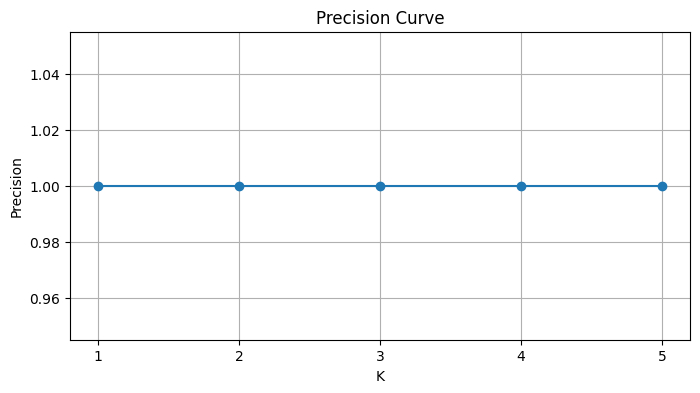

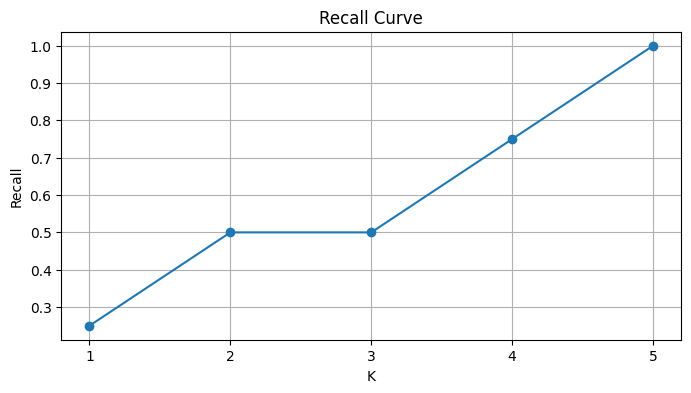

In [ ]:
import matplotlib.pyplot as plt

def precision_recall_curve(actual, predicted):
    precisions = []
    recalls = []

    for k in range(1, len(predicted) + 1):
        precision = precision_at_k(actual, predicted, k)
        recall = recall_at_k(actual, predicted, k)
        precisions.append(precision)
        recalls.append(recall)

    return precisions, recalls

# Example usage
actual_items = ["squid roast", "squid fry", "squid masala", "squid sukka"]
predicted_items = ['squid roast', 'squid sukka', 'squid biriyani', 'squid masala', 'squid fry']

# Calculate precision and recall at different values of K
precisions, recalls = precision_recall_curve(actual_items, predicted_items)

# Plot Precision
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(predicted_items) + 1), precisions, marker='o', linestyle='-')
plt.xticks(range(1, len(predicted_items) + 1))  # Set x-axis ticks to integers
plt.xlabel('K')
plt.ylabel('Precision')
plt.title('Precision Curve')
plt.grid(True)
plt.show()

# Plot Recall
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(predicted_items) + 1), recalls, marker='o', linestyle='-')
plt.xticks(range(1, len(predicted_items) + 1))  # Set x-axis ticks to integers
plt.xlabel('K')
plt.ylabel('Recall')
plt.title('Recall Curve')
plt.grid(True)
plt.show()


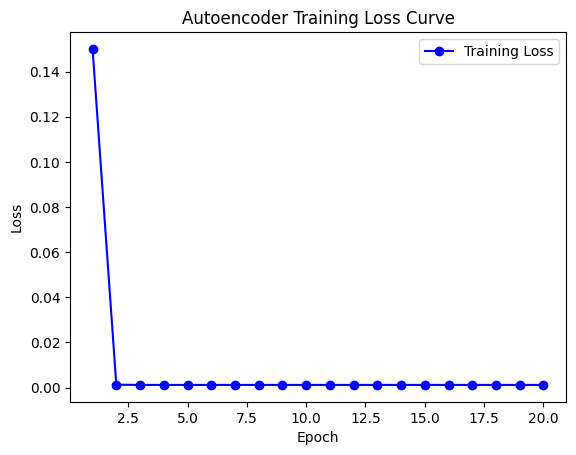

In [ ]:
import matplotlib.pyplot as plt

# Your data
x_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
y_values = [0.15, 0.0013, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012]

# Plotting the curve with labels
plt.plot(x_values, y_values, marker='o', linestyle='-', color='b', label='Training Loss')

# Adding labels and title
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Autoencoder Training Loss Curve')

# Adding legend
plt.legend()

# Display the plot
plt.show()


# implementation

In [10]:
!pip install flask-ngrok;
!pip install flask-ngrok
!pip install flask-bootstrap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 456.4/456.4 kB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Created wheel for flask-bootstrap: filename=Flask_Bootstrap-3.3.7.1-py3-none-any.whl size=460118 sha256=2e7df4cf775b4b264c0fe010977e0f04c16402a5cd770e8c250e76f5619fb199
  Stored in directory: /root/.cache/pip/wheels/6f/33/ad/26540e84a28334e5dfeda756df270f95353779f03bc5cf40d4
  Created wheel for visitor: filename=visitor-0.1.3-py3-none-any.whl size=3926 sha256=bd8873ea48b536e83e218012c6868425cad4a7ac41580f15cf109e1900f167ad
  Stored in directory: /root/.cache/pip/wheels/19/31/99/2ec5b4459cac4d801d6201d501a354366d180afc9f8bb2d333
Successfully built flask-bootstrap visitor


In [ ]:
from flask import Flask, request, jsonify,render_template
from flask_bootstrap import Bootstrap
from flask_ngrok import run_with_ngrok
from tensorflow.keras.models import Model

from google.colab import drive
drive.mount('/content/drive')

app = Flask(__name__, template_folder='/content/drive/MyDrive/websites')
run_with_ngrok(app)  # Start ngrok when the app is run

layer_name = 'conv1d_3'  # Replace with the name of the layer you want to extract
intermediate_layer_model = Model(inputs=autoencoder.input, outputs=autoencoder.get_layer(layer_name).output)
intermediate_output = intermediate_layer_model.predict(X_train)
def cosine_similarity(vector1, vector2):
    """
    Calculate the cosine similarity between two vectors.

    Parameters:
    - vector1, vector2: 1D NumPy arrays representing the vectors.

    Returns:
    - Similarity score between -1 and 1.
    """
    dot_product = np.dot(vector1, vector2)
    norm_vector1 = np.linalg.norm(vector1)
    norm_vector2 = np.linalg.norm(vector2)

    similarity = dot_product / (norm_vector1 * norm_vector2)

    return similarity


# Replace this with your actual recommendation function
def get_recommendations(item_id):
    # Modify this function to fetch recommendations based on the provided item_id
    # This is just a placeholder, replace it with your actual logic

    # Example: Recommendations for item ID 320
    #if item_id == 320:
    #    recommendations = ["Recommendation : - squid sukka", "Recommendation :- squid biryani", "Recommendation : - squid biryani"]
    #else:
    #    recommendations = []  # Default to an empty list for other item IDs

    nodes_list = list(G.nodes())
    # Get the index of the element
    #element_index = nodes_list.index(item_id)



    user_id = nodes_list.index(item_id)  # Replace with the desired user

    user_representation = (intermediate_output[user_id]).flatten()
    print(user_representation.shape)
    flattened_array = intermediate_output.reshape((intermediate_output.shape[0], -1))
    print(flattened_array[0].shape)
    # Calculate cosine similarity between the user and all products
    similarities=np.zeros(4896)
    for i in range(0,4896):
        similarities[i] = cosine_similarity(user_representation,flattened_array[i])

    # Get product recommendations for the user
    num_recommendations = 4
    recommended_products = np.argsort(similarities)[-num_recommendations:][::-1]
    recommendations = []
    for item in recommended_products:
      recommendations.append(nodes_list[item])
    return recommendations



@app.route('/get_recommendations', methods=['GET'])
def recommend():
    item_id = request.args.get('item_id')
    recommendations = get_recommendations(item_id)
    return jsonify({'recommendations': recommendations})


@app.route('/')
def home():
  return render_template('/menu.html')

# Added
from google.colab.output import eval_js
print(eval_js("google.colab.kernel.proxyPort(5000)"))

@app.route('/biryani.html')
def biryani():
   return render_template('/biryani.html')
@app.route('/pizza.html')
def pizza():
   return render_template('/pizza.html')
@app.route('/burger.html')
def burger():
   return render_template('/burger.html')
@app.route('/icecream.html')
def icecream():
   return render_template('/icecream.html')




if __name__ == '__main__':
    app.run()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
153/153 [==============================] - 5s 31ms/step
https://onrny7hn05-496ff2e9c6d22116-5000-colab.googleusercontent.com/
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
Exception in thread Thread-11:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/urllib3/connection.py", line 203, in _new_conn
    sock = connection.create_connection(
  File "/usr/local/lib/python3.10/dist-packages/urllib3/util/connection.py", line 85, in create_connection
    raise err
  File "/usr/local/lib/python3.10/dist-packages/urllib3/util/connection.py", line 73, in create_connection
    sock.connect(sa)
ConnectionRefusedError: [Errno 111] Connection refused

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/urllib3/connectionpool.py", line 791, in urlopen
    response = self._make_request(
  File "/usr/local/lib/python3.10/dist-packages/urll

(612,)
(612,)


In [ ]:
pip install gradio tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 50.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.1/92.1 kB 11.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.9/307.9 kB 32.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 8.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.5/138.5 kB 16.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 63.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.9/129.9 kB 14.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.8/77.8 kB 7.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 8.6 MB/s eta 0:00:00
  Created wheel for ffmpy: filename=ffmpy-0.3.2-py3-none-any.whl size

In [ ]:
import gradio as gr
import numpy as np
from tensorflow.keras.models import Model

layer_name = 'conv1d_3'  # Replace with the name of the layer you want to extract
intermediate_layer_model = Model(inputs=autoencoder.input, outputs=autoencoder.get_layer(layer_name).output)
intermediate_output = intermediate_layer_model.predict(X_train)

def cosine_similarity(vector1, vector2):
    dot_product = np.dot(vector1, vector2)
    norm_vector1 = np.linalg.norm(vector1)
    norm_vector2 = np.linalg.norm(vector2)
    if norm_vector1 == 0 or norm_vector2 == 0:
        return 0.0  # Avoid division by zero
    similarity = dot_product / (norm_vector1 * norm_vector2)
    return similarity

def recommend_products(element_to_find):
    if element_to_find not in nodes_list:
        return ["Product not found in the dataset. Please enter a valid product name."]

    element_index = nodes_list.index(element_to_find)
    product_representation = intermediate_output[element_index].flatten()
    flattened_array = intermediate_output.reshape((intermediate_output.shape[0], -1))

    similarities = np.zeros(flattened_array.shape[0])
    for i in range(flattened_array.shape[0]):
        similarities[i] = cosine_similarity(product_representation, flattened_array[i])

    num_recommendations = 5
    recommended_products = np.argsort(similarities)[-num_recommendations:][::-1]

    recommended_product_names = [nodes_list[item] for item in recommended_products]

    return recommended_product_names

iface = gr.Interface(
    fn=recommend_products,
    inputs=gr.Textbox(),
    outputs=gr.Textbox(),
    live=True,
    title="Product Recommender",
    description="Enter product name to get recommendations.")

iface.launch(debug=True)


153/153 [==============================] - 6s 38ms/step
Setting queue=True in a Colab notebook requires sharing enabled. Setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
Running on public URL: https://6d1e37b37cbdaf24c2.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)
